Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Constants and Global variables

In [2]:
INTERGENIC_TES_DISTANCES = "C:\\Users\\Ana\\Documents\\Estágio\\Tanaka2014\\TE_Intergenic_With_Distances.bed"
EXPRESSION_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Tanaka2014\\Expression_TE_DESeq.csv"
THRESHOLD_DISTANCE = 4000
CLINICAL_DATA = "C:\\Users\\Ana\\Documents\\Estágio\\Tanaka2014\\SraRunTable_Tanaka2014.csv"

Histogram

     0        1        2                3     4  5    6     7     8        9   \
0  chr1   923332   923423     TE_MIR_dup18   265  +  MIR  SINE  chr1   923922   
1  chr1  1253320  1253587   TE_AluJb_dup67  1581  -  Alu  SINE  chr1  1253908   
2  chr1  1407799  1407953  TE_AluSx3_dup14   854  -  Alu  SINE  chr1  1401908   
3  chr1  1408001  1408288   TE_AluJb_dup76  1799  +  Alu  SINE  chr1  1409095   
4  chr1  1408480  1408622    TE_L1MC4_dup4   281  -   L1  LINE  chr1  1401908   

        10         11 12 13    14  
0   944575     SAMD11  .  +   500  
1  1273864     UBE2J2  .  -   322  
2  1407293     MRPL20  .  -   507  
3  1410618  MRPL20-DT  .  +   808  
4  1407293     MRPL20  .  -  1188  
     Start     End  Count
0      1.0   500.9   1204
1    500.9  1000.8   1061
2   1000.8  1500.7    912
3   1500.7  2000.6    786
4   2000.6  2500.5    685
5   2500.5  3000.4    614
6   3000.4  3500.3    524
7   3500.3  4000.2    484
8   4000.2  4500.1    397
9   4500.1  5000.0    367
10  5000.0 

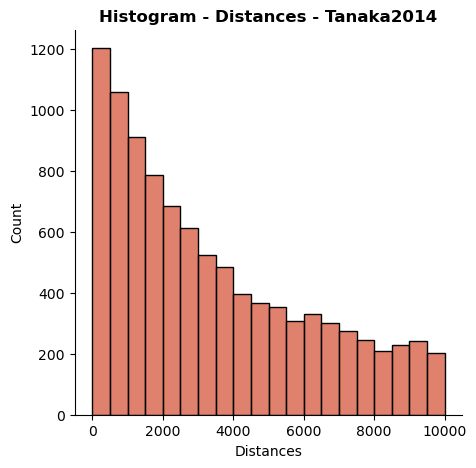

In [3]:
TEs_df = pd.read_csv(INTERGENIC_TES_DISTANCES, sep = '\t', header = None)
print(TEs_df.head())

TEs_df.columns = ['TE_Chr', 'TE_Start', 'TE_End', 'TE_Name', 'TE_Score', 'TE_Strand', 'TE_Class-id', 'TE_Family_id',
                 'Gene_Chr', 'Gene_Start', 'Gene_End', 'Gene_Name', 'Gene_Score', 'Gene_Strand', 'Distances']

def plot_histogram(df):
    fig, ax = plt.subplots(figsize = (5,5))

    final_df = df[df['Distances'] < 10000]

    sns.histplot(data = final_df, x = 'Distances', bins = 20, color = '#D5573B')

    ax.set_title('Histogram - Distances - Tanaka2014', fontweight = 'bold', fontsize = 12)
    sns.despine()
    plt.plot()
    get_count(ax)

def get_count(ax): # Alternativamente podia utilizar o numpy.histogram
    patches = ax.patches # Uma patch é um objeto gráfico 2D que representa uma forma geométrica (ou seja é tipo os pontos e as barras)
    bin_count = []
    bin_edges = []

    for patch in patches: # Só há 20 barras, há uma que não vai ficar nas edges
        bin_count.append(patch.get_height()) # Também podia ter feito bin_count = [patch for patch in patches], mas assim é mais eficiente
        bin_edges.append(patch.get_x())

    bin_width = patch.get_width()
    bin_edges.append(patches[-1].get_x() + bin_width) # Para conseguir a última edge

    hist_df = pd.DataFrame( {
                'Start' : bin_edges[:-1],
                'End' : bin_edges[1:],
                'Count' : bin_count
    }
    )
    print(hist_df)

plot_histogram(TEs_df)


PCA - Intergenics Data

In [4]:
# Read files
expr_df = pd.read_csv(EXPRESSION_FILE)
clinical_df = pd.read_csv(CLINICAL_DATA)

# Merge to get intergenic
print(TEs_df)
expr_df = expr_df.rename(columns = {'Unnamed: 0' : 'TE_Name'})
TEs_df = TEs_df[['TE_Name']]
expr_df = expr_df.merge(TEs_df, on = 'TE_Name', how = 'inner')

# Organize expression file
TEs_names = expr_df['TE_Name']
counts = expr_df.iloc[:, 1:]

# Organize clinical data
clinical_df['Condition'] = clinical_df['mutation'].apply(lambda x: 'WT' if x == 'no' else 'RTT')
clinical_df.loc[clinical_df['treatment'] != 'no', 'Condition'] = 'shMECP2'
clinical_df.loc[ clinical_df['Run'].isin(['SRR1015689', 'SRR1015687', 'SRR1015691', 'SRR1015690']) |
                  (clinical_df['mutation'] == 'no')
                  ]

clinical_data = clinical_df[clinical_df['Condition'].isin(['WT', 'RTT'])]

clinical_df = clinical_df[['Sample Name', 'Run', 'Condition']]
print(clinical_df)

# Make log2cpm
library_size = counts.sum(axis = 0)
cpm_df = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm_df + 1)


# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

# PCA
pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# Merge it all
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)]) # Os nomes das amostras ficam como index e as colunas são as componentes principais
pca_df.reset_index(names = 'Sample Name', inplace = True)
pca_df = pca_df.merge(clinical_df, on = 'Sample Name', how = 'left')

pca_df.head()


      TE_Chr  TE_Start    TE_End               TE_Name  TE_Score TE_Strand  \
0       chr1    923332    923423          TE_MIR_dup18       265         +   
1       chr1   1253320   1253587        TE_AluJb_dup67      1581         -   
2       chr1   1407799   1407953       TE_AluSx3_dup14       854         -   
3       chr1   1408001   1408288        TE_AluJb_dup76      1799         +   
4       chr1   1408480   1408622         TE_L1MC4_dup4       281         -   
...      ...       ...       ...                   ...       ...       ...   
22203   chrY  19696400  19697946      TE_L1MA7_dup8837      6361         +   
22204   chrY  19792396  19797638      TE_L1PA6_dup6079     21037         -   
22205   chrY  19834098  19840237     TE_L1PA4_dup12182     24414         -   
22206   chrY  20900464  20900798  TE_HERVH-int_dup5961      1984         +   
22207   chrY  21035919  21036418       TE_LTR7_dup2416      3056         -   

      TE_Class-id TE_Family_id Gene_Chr  Gene_Start  Gene_End  

,Sample Name,PC1,PC2,Run,Condition
0,GSM1249124,51.662791,40.227458,SRR1015685,WT
1,GSM1249126,-38.422531,-161.665557,SRR1015687,RTT
2,GSM1249130,27.446020,7.844592,SRR1015691,RTT
3,GSM1249122,78.653539,23.953011,SRR1015683,WT
4,GSM1249123,25.217314,37.521544,SRR1015684,WT


PCA - Graph

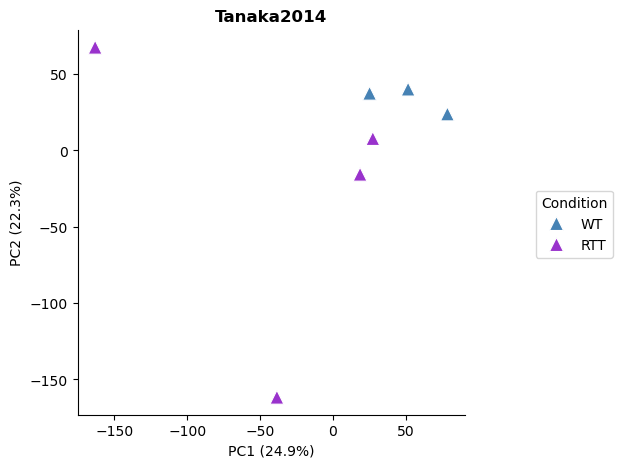

In [6]:
fig, ax = plt.subplots(figsize = (5, 5))

palette_pca = {
    'RTT' : 'darkorchid',
    'WT' : 'steelblue'
}

sns.scatterplot(pca_df, x = 'PC1', y = 'PC2', palette = palette_pca, hue = 'Condition', s = 100, marker = '^')

# Labels
ax.set_title('Tanaka2014', fontweight = 'bold', fontsize = 12)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))


sns.despine()
plt.show()
